# El pronóstico de huracanes ganó 23 horas en una década. Google dice que gana un día de golpe

El centro de huracanes de Estados Unidos tardó diez años de trabajo en adelantar su aviso 22,9 horas. Un modelo de IA publicado hoy en *Nature* afirma que adelanta un día o más — de una sola vez.

Esa comparación es el corazón del paper. Y es la que podemos poner a prueba con datos públicos.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Operational Tropical Cyclone Forecasting with AI* · Alet et al., **Nature** (6 de agosto de 2026)

**DOI:** [10.1038/s41586-026-10953-2](https://doi.org/10.1038/s41586-026-10953-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-06-ciclones-tropicales-ia/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/N_MrgrSR2ec)

## Qué construyeron

WeatherNext Cyclones (WN-C) es un modelo de IA de Google DeepMind que genera montones de escenarios posibles del mismo ciclón — un «ensamble» — y para cada uno dice por dónde va a pasar, con qué fuerza y hasta dónde llegan sus vientos dañinos (los radios de viento), hasta 15 días hacia adelante. Puede correr hasta 1.000 miembros donde los sistemas convencionales corren 50 — y ese volumen es justo lo que hace falta para que aparezcan los escenarios raros.

Lo evaluaron sobre los ciclones de 2023 a 2025 y reportan una ventaja media de **un día o más de anticipación** frente a los modelos operativos líderes.

Aquí viene el problema: el paper no publica los datos de sus tablas de resultados, así que no podemos recalcular su ventaja. Pero sí podemos hacer algo más interesante — **reconstruir la vara con la que se mide esa ventaja**. Las dos fuentes públicas sobre las que el paper se apoya están descargables: el archivo histórico de ciclones IBTrACS y el archivo de verificación del centro de huracanes de EE. UU. (NHC).

Con eso respondemos la pregunta que el titular no responde: *¿un día de anticipación es mucho?*

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_PISTA_KM   = 300      # Error de pista que define "aviso útil" (el mismo del paper, SI §2.7.1)
HORIZONTE_ZOOM_H  = 48       # Horizonte de pronóstico para las series anuales
ANIO_INICIO_SERIE = 1990     # El error de intensidad del NHC solo existe desde 1990
CORTE_PERIODOS    = 2010     # Año que separa los dos periodos de intensidad

FUENTE = ('Fuente: Alet et al. (2026), Nature | Datos: NOAA NHC Forecast Verification '
          'e IBTrACS v04r01')

COLOR_DATOS      = '#2563EB'   # Atlántico / serie principal
COLOR_ALERTA     = '#DC2626'   # Contraste
COLOR_SECUNDARIO = '#059669'   # Pacífico Nororiental
COLOR_REFERENCIA = '#D97706'   # Umbrales y censura
COLOR_CONTEXTO   = '#BBBBBB'

# ── Setup ─────────────────────────────────────────────────────
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo editorial CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga ─────────────────────────────────────────────────────
BASE = 'datos' if os.path.exists('datos/nhc_decadas.csv') else '/home/jupyter/datos'

# IBTrACS: BASIN='NA' (Atlántico Norte) se parsea como NaN con el default de pandas.
# keep_default_na=False lo evita; la columna 'cuenca' ya viene resuelta en el CSV.
tormentas = pd.read_csv(f'{BASE}/ibtracs_tormentas_2023_2025.csv',
                        keep_default_na=False, na_values=[''])
decadas = pd.read_csv(f'{BASE}/nhc_decadas.csv')
anual = pd.read_csv(f'{BASE}/nhc_error_anual.csv')

NOMBRE_CUENCA = {'ATL': 'Atlántico Norte', 'EPAC': 'Pacífico Nororiental'}

print(f'IBTrACS 2023-2025 : {len(tormentas):>6} tormentas en {tormentas.cuenca.nunique()} cuencas')
print(f'NHC por décadas   : {len(decadas):>6} filas ({decadas.cuenca.nunique()} cuencas '
      f'x {decadas.periodo.nunique()} periodos x {decadas.lead_h.nunique()} horizontes)')
print(f'NHC anual         : {len(anual):>6} filas ({anual.anio.min()}-{anual.anio.max()})')
print()
print('Horizontes disponibles (h):', [int(h) for h in sorted(decadas.lead_h.unique())])
print('Periodos:', sorted(decadas.periodo.unique()))

IBTrACS 2023-2025 :    256 tormentas en 6 cuencas
NHC por décadas   :     42 filas (2 cuencas x 3 periodos x 7 horizontes)
NHC anual         :    536 filas (1970-2025)

Horizontes disponibles (h): [12, 24, 36, 48, 72, 96, 120]
Periodos: ['1995-2004', '2005-2014', '2015-2024']


## Cuánto vale una década

El paper mide el progreso así: fijas un error de pista tolerable — 300 km — y preguntas cuántas horas antes el pronóstico ya se mantiene por debajo. Mientras más horas, más margen para evacuar.

Aquí está.

Anticipación con error medio bajo 300 km:

  Atlántico Norte        1995-2004:               59.9 h
  Atlántico Norte        2005-2014:               90.0 h
  Atlántico Norte        2015-2024:              112.8 h
  Pacífico Nororiental   1995-2004:               66.0 h
  Pacífico Nororiental   2005-2014:              112.2 h
  Pacífico Nororiental   2015-2024:   >120 h (censurado)

Atlántico — ganancia 2005-2014 -> 2015-2024: 22.9 h
Atlántico — ganancia 1995-2004 -> 2005-2014: 30.1 h


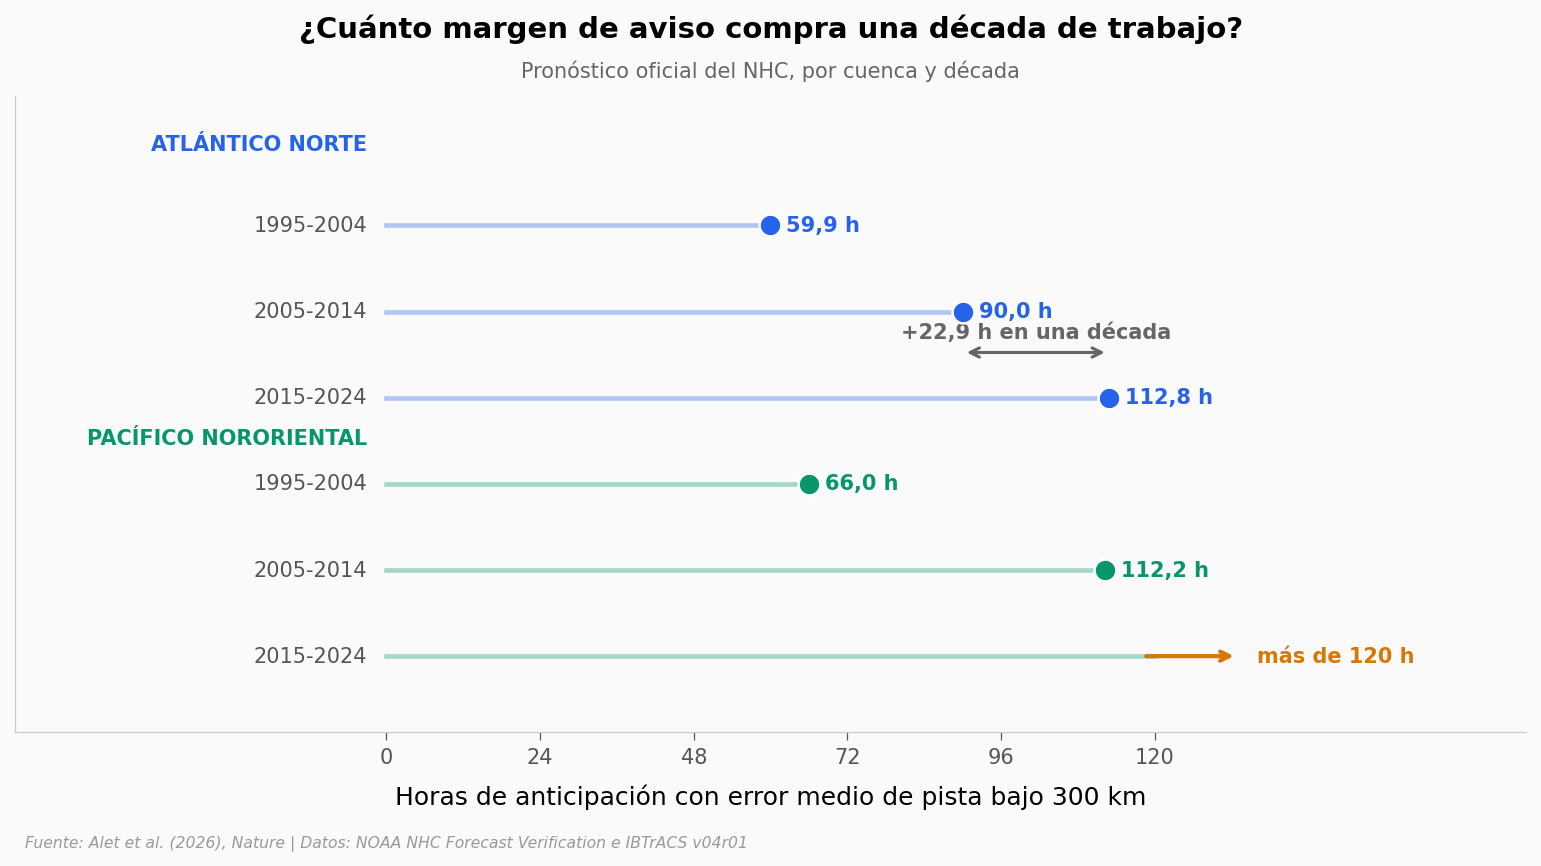

In [2]:
def lead_time_a_umbral(sub, umbral=UMBRAL_PISTA_KM):
    """Horas de anticipación con las que el error medio se mantiene bajo `umbral`.

    Interpola la curva error-vs-horizonte. Devuelve None si el error nunca
    alcanza el umbral dentro de las 120 h medidas (dato CENSURADO, no faltante).
    """
    s = sub.sort_values('lead_h')
    x, y = s.lead_h.values.astype(float), s.error_pista_km.values.astype(float)
    if y.max() < umbral:
        return None
    return float(np.interp(umbral, y, x))


filas = []
for (cuenca, periodo), sub in decadas.groupby(['cuenca', 'periodo']):
    filas.append({'cuenca': cuenca, 'periodo': periodo,
                  'lead_h': lead_time_a_umbral(sub),
                  'error_max_km': sub.error_pista_km.max()})
lead = pd.DataFrame(filas).sort_values(['cuenca', 'periodo'])

print(f'Anticipación con error medio bajo {UMBRAL_PISTA_KM} km:\n')
for _, r in lead.iterrows():
    valor = f'{r.lead_h:.1f} h' if pd.notna(r.lead_h) else '>120 h (censurado)'
    print(f'  {NOMBRE_CUENCA[r.cuenca]:<22} {r.periodo}: {valor:>20}')

atl = lead[lead.cuenca == 'ATL'].set_index('periodo').lead_h
gan_ultima = atl['2015-2024'] - atl['2005-2014']
gan_previa = atl['2005-2014'] - atl['1995-2004']
print(f'\nAtlántico — ganancia 2005-2014 -> 2015-2024: {gan_ultima:.1f} h')
print(f'Atlántico — ganancia 1995-2004 -> 2005-2014: {gan_previa:.1f} h')

# ── Gráfica ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

periodos = ['1995-2004', '2005-2014', '2015-2024']
config = [('ATL', COLOR_DATOS, [2.6, 1.8, 1.0]),
          ('EPAC', COLOR_SECUNDARIO, [0.2, -0.6, -1.4])]

for cuenca, color, ys in config:
    sub = lead[lead.cuenca == cuenca].set_index('periodo')
    for periodo, y in zip(periodos, ys):
        v = sub.loc[periodo, 'lead_h']
        if pd.notna(v):
            ax.plot([0, v], [y, y], color=color, linewidth=2.2, alpha=0.35, zorder=3)
            ax.scatter([v], [y], color=color, s=110, zorder=5, edgecolors='white',
                       linewidths=1.2)
            ax.text(v + 2.5, y, f'{v:.1f} h'.replace('.', ','), va='center',
                    fontsize=10, fontweight='bold', color=color)
        else:
            # Censurado: el error nunca llega al umbral dentro de las 120 h medidas
            ax.plot([0, 120], [y, y], color=color, linewidth=2.2, alpha=0.35, zorder=3)
            ax.annotate('', xy=(133, y), xytext=(118, y),
                        arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=2))
            ax.text(136, y, 'más de 120 h', va='center', fontsize=10,
                    fontweight='bold', color=COLOR_REFERENCIA)
        ax.text(-3, y, periodo, va='center', ha='right', fontsize=10, color='#555555')

ax.text(-3, 3.35, 'ATLÁNTICO NORTE', va='center', ha='right', fontsize=10,
        fontweight='bold', color=COLOR_DATOS)
ax.text(-3, 0.95 - 0.15, '', va='center')
ax.text(-3, 0.62, 'PACÍFICO NORORIENTAL', va='center', ha='right', fontsize=10,
        fontweight='bold', color=COLOR_SECUNDARIO)

# La ganancia de la última década en el Atlántico
ax.annotate('', xy=(atl['2015-2024'], 1.42), xytext=(atl['2005-2014'], 1.42),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((atl['2015-2024'] + atl['2005-2014']) / 2, 1.55,
        f'+{gan_ultima:.1f} h en una década'.replace('.', ','),
        ha='center', fontsize=10, fontweight='bold', color='#666666')

ax.set_ylim(-2.1, 3.8)
ax.set_xlim(-58, 178)
ax.set_yticks([])
ax.set_xticks([0, 24, 48, 72, 96, 120])
ax.set_xlabel('Horas de anticipación con error medio de pista bajo 300 km')
ax.grid(axis='y', visible=False)
ax.set_title('¿Cuánto margen de aviso compra una década de trabajo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Pronóstico oficial del NHC, por cuenca y década',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/lead_time_decadas.png', dpi=200, bbox_inches='tight')
plt.show()

En el Atlántico, la anticipación pasó de 59,9 h a 90,0 h y luego a 112,8 h. La última década sumó **22,9 h**; la anterior había sumado 30,1 h. El avance sigue, pero cada década rinde un poco menos que la anterior.

Y ahí está la coincidencia que da sentido al titular: el paper calcula, con su propio método, que el ensamble del centro europeo (ECMWF ENS) ganó **unas 22 h** entre esas mismas dos décadas. Nosotros obtuvimos 22,9 h.

Ojo con qué significa eso: son **modelos y ámbitos distintos** (el pronóstico oficial del NHC en el Atlántico frente al ensamble europeo a escala global). No reprodujimos su cálculo; llegamos a un número parecido por un camino independiente. Que dos rutas distintas den ~22 h es lo que vuelve creíble la vara.

El Pacífico Nororiental trae el dato más incómodo del gráfico: en 2015-2024 el error medio **nunca llega a 300 km** dentro de los 5 días que el NHC verifica. Eso no es un hueco en los datos — es que la escala se quedó corta. Con la vara de 300 km, esa cuenca ya está fuera de rango.

## La serie detrás de la vara

Las décadas son un promedio. Debajo hay 36 años de pronósticos verificados uno por uno.

Serie: 1990-2025, n = 36 años
Shapiro-Wilk p = 0.0130 -> no normal, usamos Spearman
Spearman rho = -0.948 (p = 1.63e-18)
Pendiente de la recta: -7.68 km/año

1990: 359.6 km   |   2024: 84.4 km   |   2025: 98.5 km


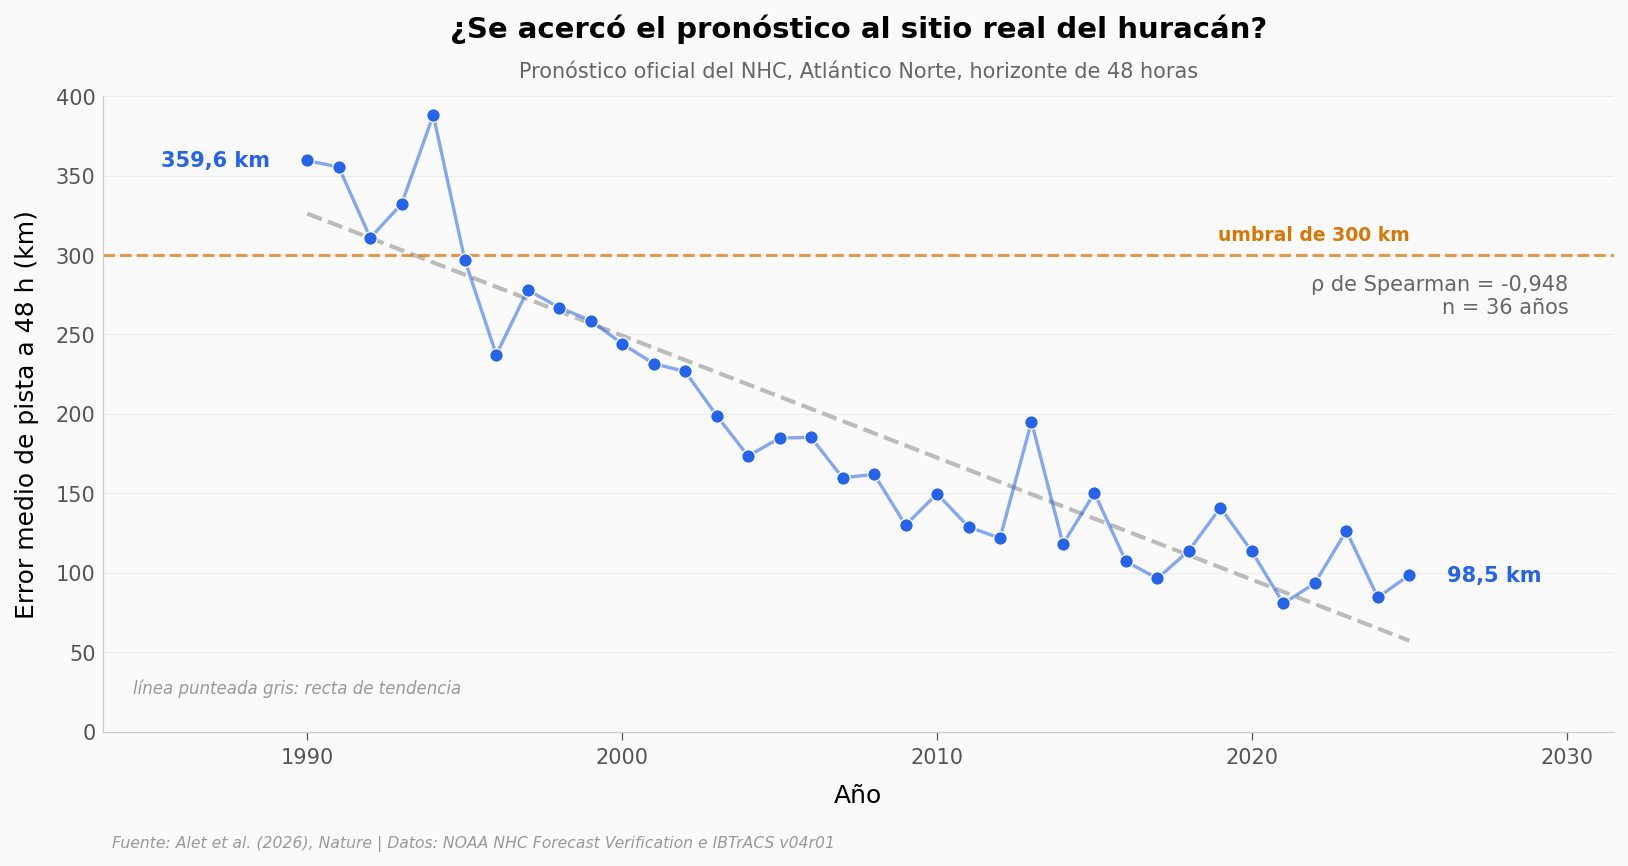

In [3]:
serie = (anual[(anual.cuenca == 'ATL') & (anual.lead_h == HORIZONTE_ZOOM_H)
               & (anual.anio >= ANIO_INICIO_SERIE)]
         .dropna(subset=['error_pista_km']).sort_values('anio'))

# Shapiro-Wilk decide el test de correlación (regla: Spearman por defecto)
sh_p = stats.shapiro(serie.error_pista_km).pvalue
rho, p_rho = stats.spearmanr(serie.anio, serie.error_pista_km)
pendiente, intercepto, _, _, _ = stats.linregress(serie.anio, serie.error_pista_km)

print(f'Serie: {serie.anio.min()}-{serie.anio.max()}, n = {len(serie)} años')
print(f'Shapiro-Wilk p = {sh_p:.4f} -> {"no normal" if sh_p < 0.05 else "normal"}, '
      f'usamos Spearman')
print(f'Spearman rho = {rho:.3f} (p = {p_rho:.2e})')
print(f'Pendiente de la recta: {pendiente:.2f} km/año')
print(f'\n{serie.anio.min()}: {serie.error_pista_km.iloc[0]:.1f} km   |   '
      f'2024: {serie[serie.anio == 2024].error_pista_km.iloc[0]:.1f} km   |   '
      f'2025: {serie.error_pista_km.iloc[-1]:.1f} km')

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(serie.anio, intercepto + pendiente * serie.anio, color=COLOR_CONTEXTO,
        linewidth=2, linestyle='--', zorder=2)
ax.plot(serie.anio, serie.error_pista_km, color=COLOR_DATOS, linewidth=1.6,
        alpha=0.55, zorder=3)
ax.scatter(serie.anio, serie.error_pista_km, color=COLOR_DATOS, s=42, zorder=5,
           edgecolors='white', linewidths=0.6)

ax.axhline(y=UMBRAL_PISTA_KM, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.7)
ax.text(serie.anio.max(), UMBRAL_PISTA_KM + 9, 'umbral de 300 km', ha='right',
        fontsize=9, fontweight='bold', color=COLOR_REFERENCIA)

# Etiquetas a los flancos de la serie: dentro del lienzo no hay hueco libre
for anio, dx, ha in [(serie.anio.min(), -1.2, 'right'), (serie.anio.max(), 1.2, 'left')]:
    fila = serie[serie.anio == anio].iloc[0]
    ax.text(anio + dx, fila.error_pista_km, f'{fila.error_pista_km:.1f} km'.replace('.', ','),
            va='center', ha=ha, fontsize=10, fontweight='bold', color=COLOR_DATOS)
ax.set_xlim(serie.anio.min() - 6.5, serie.anio.max() + 6.5)

ax.text(0.97, 0.72, f'ρ de Spearman = {rho:.3f}'.replace('.', ',') + f'\nn = {len(serie)} años',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='right', va='top')
ax.text(0.02, 0.06, 'línea punteada gris: recta de tendencia', transform=ax.transAxes,
        fontsize=8, color='#999999', style='italic')

ax.set_ylabel('Error medio de pista a 48 h (km)')
ax.set_xlabel('Año')
ax.set_ylim(0, 400)
ax.set_title('¿Se acercó el pronóstico al sitio real del huracán?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Pronóstico oficial del NHC, Atlántico Norte, horizonte de 48 horas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/serie_pista_atlantico.png', dpi=200, bbox_inches='tight')
plt.show()

Bajar de 359,6 km a 98,5 km en 36 años es una caída del 72,6 %, y la correlación de rangos con el año es de las más limpias que se ven en un dato real: ρ = -0,948.

Pero acertarle al rumbo es solo la mitad del pronóstico. La otra mitad es **con qué fuerza** llega — y esa mitad tiene otra historia.

1990-2009: media 16.17 kt (n = 20 años)
2010-2025: media 11.72 kt (n = 16 años)
Diferencia: 4.44 kt
Mann-Whitney U p = 1.29e-05 | Cohen's d (pooled) = 2.03 -> efecto grande

Tendencia DENTRO de cada periodo:
  1990-2009: -0.081 kt/año, p = 0.363 -> NO significativa
  2010-2025: -0.191 kt/año, p = 0.102 -> NO significativa


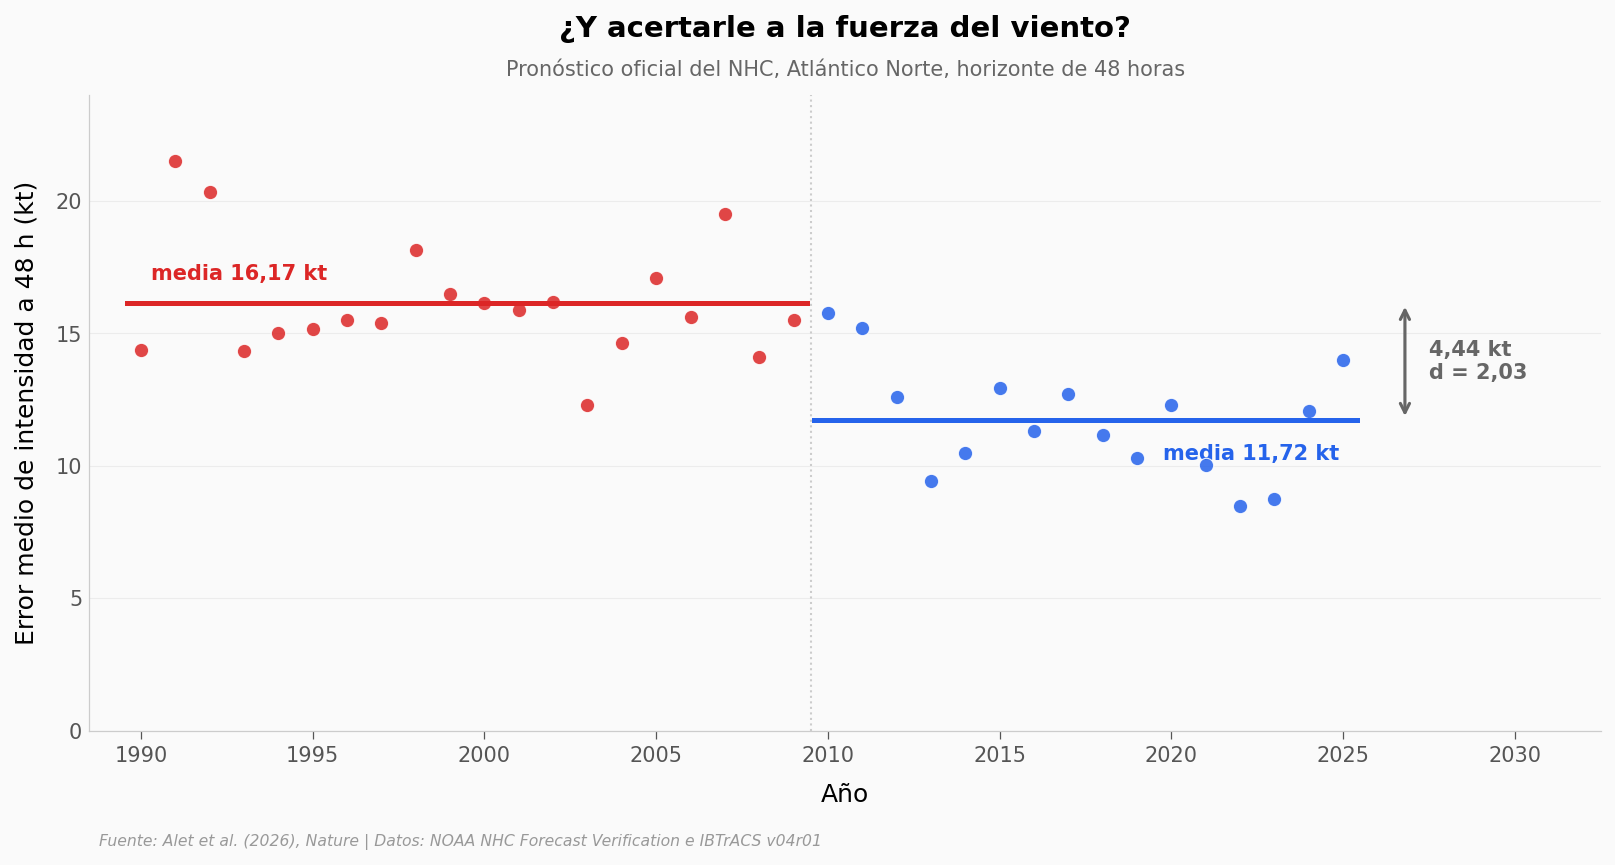

In [4]:
inten = (anual[(anual.cuenca == 'ATL') & (anual.lead_h == HORIZONTE_ZOOM_H)
               & (anual.anio >= ANIO_INICIO_SERIE)]
         .dropna(subset=['error_intensidad_kt']).sort_values('anio'))

antes = inten[inten.anio < CORTE_PERIODOS]
despues = inten[inten.anio >= CORTE_PERIODOS]

# Comparación entre periodos: años distintos en cada grupo -> muestras independientes
u = stats.mannwhitneyu(antes.error_intensidad_kt, despues.error_intensidad_kt,
                       alternative='two-sided')
n1, n2 = len(antes), len(despues)
sd_pooled = np.sqrt(((n1 - 1) * antes.error_intensidad_kt.var(ddof=1) +
                     (n2 - 1) * despues.error_intensidad_kt.var(ddof=1)) / (n1 + n2 - 2))
d = (antes.error_intensidad_kt.mean() - despues.error_intensidad_kt.mean()) / sd_pooled

print(f'{ANIO_INICIO_SERIE}-{CORTE_PERIODOS - 1}: media {antes.error_intensidad_kt.mean():.2f} kt '
      f'(n = {n1} años)')
print(f'{CORTE_PERIODOS}-{inten.anio.max()}: media {despues.error_intensidad_kt.mean():.2f} kt '
      f'(n = {n2} años)')
print(f'Diferencia: {antes.error_intensidad_kt.mean() - despues.error_intensidad_kt.mean():.2f} kt')
print(f'Mann-Whitney U p = {u.pvalue:.2e} | Cohen\'s d (pooled) = {d:.2f} -> efecto grande')
print()
print('Tendencia DENTRO de cada periodo:')
for etiqueta, grupo in [(f'{ANIO_INICIO_SERIE}-{CORTE_PERIODOS - 1}', antes),
                        (f'{CORTE_PERIODOS}-{inten.anio.max()}', despues)]:
    s, _, _, p_s, _ = stats.linregress(grupo.anio, grupo.error_intensidad_kt)
    print(f'  {etiqueta}: {s:+.3f} kt/año, p = {p_s:.3f} '
          f'-> {"significativa" if p_s < 0.05 else "NO significativa"}')

fig, ax = plt.subplots(figsize=(13, 5.5))
# Cada etiqueta va en el hueco libre de su tramo: arriba-izquierda en el primero,
# abajo-derecha en el segundo. Los demás cuadrantes los ocupan los puntos.
for grupo, color, ancla, ha, dy, va in [
        (antes, COLOR_ALERTA, 'min', 'left', 0.7, 'bottom'),
        (despues, COLOR_DATOS, 'max', 'right', -0.9, 'top')]:
    ax.scatter(grupo.anio, grupo.error_intensidad_kt, color=color, s=48, alpha=0.85,
               zorder=5, edgecolors='white', linewidths=0.6)
    m = grupo.error_intensidad_kt.mean()
    ax.plot([grupo.anio.min() - 0.4, grupo.anio.max() + 0.4], [m, m], color=color,
            linewidth=2.4, zorder=6)
    x_lbl = grupo.anio.min() + 0.3 if ancla == 'min' else grupo.anio.max() - 0.1
    ax.text(x_lbl, m + dy, f'media {m:.2f} kt'.replace('.', ','),
            ha=ha, va=va, fontsize=10, fontweight='bold', color=color)

ax.axvline(x=CORTE_PERIODOS - 0.5, color='#CCCCCC', linewidth=1, linestyle=':')

# Diferencia entre periodos, fuera de la nube de puntos
x_delta = inten.anio.max() + 1.8
ax.annotate('', xy=(x_delta, despues.error_intensidad_kt.mean()),
            xytext=(x_delta, antes.error_intensidad_kt.mean()),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(x_delta + 0.7,
        (antes.error_intensidad_kt.mean() + despues.error_intensidad_kt.mean()) / 2,
        (f'{antes.error_intensidad_kt.mean() - despues.error_intensidad_kt.mean():.2f} kt\n'
         f'd = {d:.2f}').replace('.', ','),
        fontsize=10, fontweight='bold', color='#666666', va='center')

ax.set_ylabel('Error medio de intensidad a 48 h (kt)')
ax.set_xlabel('Año')
ax.set_ylim(0, 24)
ax.set_xlim(inten.anio.min() - 1.5, inten.anio.max() + 7.5)
ax.set_title('¿Y acertarle a la fuerza del viento?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Pronóstico oficial del NHC, Atlántico Norte, horizonte de 48 horas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/intensidad_periodos.png', dpi=200, bbox_inches='tight')
plt.show()

El salto entre periodos es grande (4,44 kt, d = 2,03), pero **dentro** de cada periodo no hay tendencia significativa (p = 0,363 y p = 0,102). Ojo con leer eso como ausencia de tendencia: con 20 y 16 años por grupo el test se queda corto de potencia, y sobre la serie completa 1990-2025 la caída sí es significativa (-0,214 kt/año, p = 6,3 × 10⁻⁷). Lo que los datos soportan es que la mejora se concentra alrededor del cambio de década, no que el año a año esté plano.

Concuerda con el historial del NHC que cita el paper: los errores de intensidad no mejoraron sustancialmente hasta cerca de 2010. Por qué se movió justo ahí, esta serie no lo puede decidir.

Y ese es el frente que llevaba décadas atascado. El paper reporta ventaja de WN-C también en intensidad — pero su «un día o más» es un promedio sobre pista, intensidad y radios de viento, no una cifra por separado para cada una.

Falta una pregunta: **¿sobre qué tormentas se juega todo esto?**

Tormentas 2023-2025 (naturaleza tropical/subtropical, viento máx >= 34 kt): 256
Viento máximo: mediana 65 kt, IQR 45-110 kt, rango 35-165 kt
Asimetría (skew) = 0.60 -> cola derecha, distribución dispersa
Alcanzaron fuerza de huracán (>= 64 kt): 139 (54.3 %)
Huracanes mayores (>= 96 kt): 77 (30.1 %)

Por cuenca:
  Pacífico Noroccidental    66
  Atlántico Norte           51
  Pacífico Nororiental      51
  Índico Sur                47
  Pacífico Sur              24
  Índico Norte              17


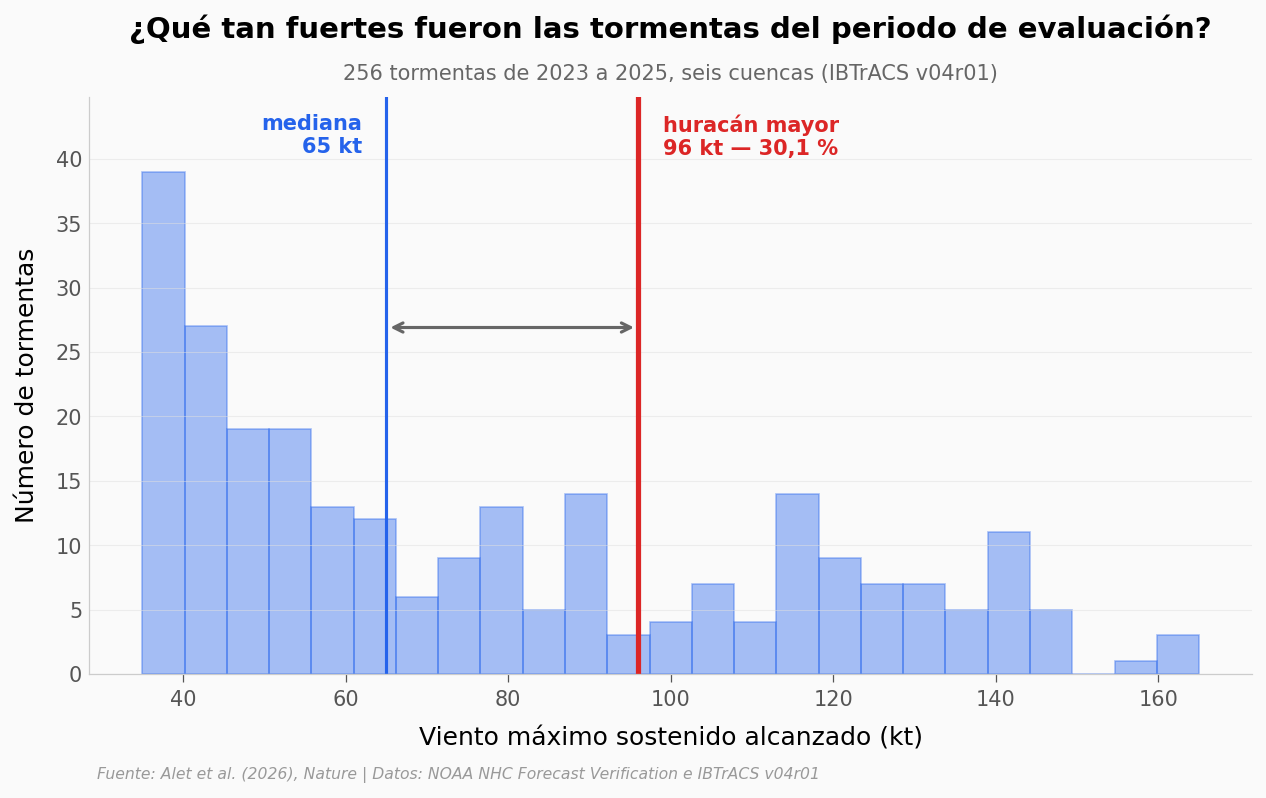

In [5]:
UMBRAL_HURACAN_KT = 64   # Categoría 1 en la escala Saffir-Simpson
UMBRAL_MAYOR_KT   = 96   # Categoría 3 — "huracán mayor"

viento = tormentas.viento_max_kt
mediana = viento.median()
q1, q3 = viento.quantile(0.25), viento.quantile(0.75)
pct_huracan = 100 * (viento >= UMBRAL_HURACAN_KT).mean()
pct_mayor = 100 * (viento >= UMBRAL_MAYOR_KT).mean()

print(f'Tormentas 2023-2025 (naturaleza tropical/subtropical, viento máx >= 34 kt): {len(viento)}')
print(f'Viento máximo: mediana {mediana:.0f} kt, IQR {q1:.0f}-{q3:.0f} kt, '
      f'rango {viento.min():.0f}-{viento.max():.0f} kt')
print(f'Asimetría (skew) = {viento.skew():.2f} -> cola derecha, distribución dispersa')
print(f'Alcanzaron fuerza de huracán (>= {UMBRAL_HURACAN_KT} kt): '
      f'{(viento >= UMBRAL_HURACAN_KT).sum()} ({pct_huracan:.1f} %)')
print(f'Huracanes mayores (>= {UMBRAL_MAYOR_KT} kt): '
      f'{(viento >= UMBRAL_MAYOR_KT).sum()} ({pct_mayor:.1f} %)')
print()
print('Por cuenca:')
for cuenca, n in tormentas.cuenca.value_counts().items():
    print(f'  {cuenca:<24} {n:>3}')

fig, ax = plt.subplots(figsize=(10, 5))
n_bins, bins, _ = ax.hist(viento, bins=25, color=COLOR_DATOS, alpha=0.4,
                          edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_bins.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5)
ax.text(mediana - 3, y_max * 0.97, f'mediana\n{mediana:.0f} kt', ha='right', va='top',
        fontsize=10, fontweight='bold', color=COLOR_DATOS)

ax.axvline(x=UMBRAL_MAYOR_KT, color=COLOR_ALERTA, linewidth=2.5)
ax.text(UMBRAL_MAYOR_KT + 3, y_max * 0.97, va='top',
        s=f'huracán mayor\n{UMBRAL_MAYOR_KT} kt — {pct_mayor:.1f} %'.replace('.', ','),
        fontsize=10, fontweight='bold', color=COLOR_ALERTA)

ax.annotate('', xy=(UMBRAL_MAYOR_KT, y_max * 0.6), xytext=(mediana, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

ax.set_xlabel('Viento máximo sostenido alcanzado (kt)')
ax.set_ylabel('Número de tormentas')
ax.set_title('¿Qué tan fuertes fueron las tormentas del periodo de evaluación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(viento)} tormentas de 2023 a 2025, seis cuencas (IBTrACS v04r01)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_viento.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

Una distinción que hay que tener presente para leer esta tabla: **no auditamos WN-C**. El paper no publica sus tablas de resultados como datos descargables, así que sus cifras se citan, no se recalculan. Lo que sí recalculamos es la referencia contra la que se compara.

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El pronóstico oficial del NHC ganó 22,9 h de anticipación (umbral 300 km) en el Atlántico entre 2005-2014 y 2015-2024 | ✅ | Calculado por interpolación sobre la curva error-vs-horizonte del archivo de verificación del NHC. El cruce del umbral cae en 90,0 h y 112,8 h, así que los horizontes que lo sostienen son 72-96 h (n = 1.219 y 935 pronósticos) y 96-120 h (n = 1.111 y 854). Es **nuestro** cálculo sobre el pronóstico oficial, no el del paper |
| Ese valor coincide con las ~22 h que el paper atribuye a una década de progreso | ⚠️ | Diferencia menor al 5 % (3,9 % sin redondear), pero son **cosas distintas**: el paper mide el ensamble ECMWF a escala global; nosotros el pronóstico oficial del NHC en el Atlántico. Es convergencia independiente, no reproducción |
| El error de pista a 48 h en el Atlántico bajó de 359,6 km (1990) a 98,5 km (2025) | ✅ | ρ de Spearman = -0,948 (p = 1,6 × 10⁻¹⁸), n = 36 años. Spearman y no Pearson porque la serie no es normal (Shapiro-Wilk p = 0,013) |
| El error de intensidad bajó 4,44 kt entre 1990-2009 y 2010-2025 | ✅ | Mann-Whitney U p = 1,3 × 10⁻⁵, Cohen's d = 2,03 (efecto grande), n = 20 vs 16 años. Ambos grupos pasan Shapiro-Wilk (p = 0,063 y p = 0,832), así que el d con SD pooled es aplicable |
| Esa mejora de intensidad es un **escalón**, no una tendencia continua | ⚠️ | Dentro de cada periodo la pendiente no es significativa (-0,081 kt/año, p = 0,363; -0,191 kt/año, p = 0,102), pero con n = 20 y n = 16 el test no tiene potencia para descartar una tendencia: sobre la serie completa 1990-2025 la caída sí es significativa (-0,214 kt/año, p = 6,3 × 10⁻⁷). Los datos son compatibles con un escalón; no lo establecen |
| En el Pacífico Nororiental 2015-2024 el error nunca alcanza 300 km en 120 h | ✅ | El error máximo medido a 120 h es 234,9 km. Es un dato **censurado**, no faltante — con esta vara la cuenca se salió de escala |
| Las 256 tormentas de 2023-2025 son el set de evaluación del paper | ⚠️ | Es **nuestro** conteo aplicando el protocolo que el paper describe (naturaleza tropical/subtropical, viento máx ≥ 34 kt) sobre IBTrACS v04r01. El paper no publica su conteo exacto — no atribuirle esta cifra |
| WN-C ofrece un día o más de ventaja sobre los modelos operativos líderes | 📄 | **Citado del paper, no verificado aquí.** Es además un promedio sobre tres cosas distintas (pista, intensidad y radios de viento) y sobre varios modelos de referencia |

> **Limitaciones:**
> - **No verificamos el modelo.** Ninguna cifra de WN-C se recalculó: el paper publica pesos y código, no los resultados tabulados de sus figuras. Todo lo que dice esta libreta sobre WN-C es cita.
> - **Quién lo evaluó.** 28 de los 32 autores son de Google DeepMind o Google Research, es decir, quienes construyeron el modelo también corrieron su evaluación. Juega a favor: hay revisión por pares y coautores del NHC, el CIRA y la Met Office — las agencias que operan los modelos de referencia. Eso no tumba el resultado, pero es parte de cómo se lee.
> - **Comparamos peras con manzanas a propósito.** Nuestra vara sale del pronóstico oficial del NHC en dos cuencas del hemisferio norte. El paper compara contra modelos globales. Sirve para dar escala a "un día", no para arbitrar quién gana.
> - **Solo dos cuencas.** El archivo de verificación del NHC cubre el Atlántico y el Pacífico Nororiental. Las otras cuatro cuencas donde operan estos ciclones no entran en la serie histórica.
> - **La vara depende del umbral.** 300 km es la elección del paper. Con otro umbral, las horas ganadas cambian — la celda experimental de abajo lo muestra.
> - **Horizontes largos, series cortas.** Los pronósticos a 96 y 120 h solo se verifican desde 2001. Cualquier gráfica que cruce horizontes arranca en años distintos.

## Ahora tú

**1. ¿Qué tan frágil es la vara de 300 km?**
Cambia `UMBRAL_PISTA_KM` en la celda de configuración a 200 o 400 y vuelve a correr. ¿La ganancia de la última década sigue siendo ~23 h, o el umbral estaba haciendo el trabajo?

**2. ¿El avance se ve igual a 24 h que a 120 h?**
Cambia `HORIZONTE_ZOOM_H` a 24, 72 o 120. Pista: a 120 h la serie arranca en 2001, no en 1990 — el eje se te va a acortar solo.

**3. ¿Y si el corte de 2010 fuera otro?**
Mueve `CORTE_PERIODOS` a 2005 o 2015 y mira qué pasa con Cohen's d. Si el efecto sobrevive a cualquier corte, el escalón es real; si solo aparece en 2010, estabas viendo el corte y no el dato.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto depende la "ganancia por década" del umbral que elegimos?
# Recalculamos la anticipación ganada para varios umbrales de error de pista.

umbrales = [150, 200, 250, 300, 350, 400]
print(f'{"Umbral":>8} | {"2005-2014":>12} | {"2015-2024":>12} | {"Ganancia":>10}')
print('-' * 52)

for u_km in umbrales:
    valores = {}
    for periodo in ['2005-2014', '2015-2024']:
        sub = decadas[(decadas.cuenca == 'ATL') & (decadas.periodo == periodo)]
        valores[periodo] = lead_time_a_umbral(sub, umbral=u_km)

    def fmt(v):
        return f'{v:.1f} h' if v is not None else '>120 h'

    if valores['2005-2014'] is not None and valores['2015-2024'] is not None:
        ganancia = f"{valores['2015-2024'] - valores['2005-2014']:+.1f} h"
    else:
        ganancia = 'censurado'

    print(f'{u_km:>6} km | {fmt(valores["2005-2014"]):>12} | '
          f'{fmt(valores["2015-2024"]):>12} | {ganancia:>10}')

print('\nLos umbrales bajos son más exigentes: el error los cruza antes, así que')
print('la anticipación es menor. Fíjate si la GANANCIA se mantiene o se deshace.')

  Umbral |    2005-2014 |    2015-2024 |   Ganancia
----------------------------------------------------
   150 km |       46.6 h |       65.5 h |    +18.9 h
   200 km |       63.0 h |       84.0 h |    +21.0 h
   250 km |       77.6 h |       99.9 h |    +22.3 h
   300 km |       90.0 h |      112.8 h |    +22.9 h
   350 km |      101.9 h |       >120 h |  censurado
   400 km |      113.4 h |       >120 h |  censurado

Los umbrales bajos son más exigentes: el error los cruza antes, así que
la anticipación es menor. Fíjate si la GANANCIA se mantiene o se deshace.


---

## Fuentes

**Paper**: [Operational Tropical Cyclone Forecasting with AI](https://doi.org/10.1038/s41586-026-10953-2)  
*Nature, 2026-08-06*

**Supplementary Material**: [Supplementary Information: Operational tropical cyclone forecasting with AI](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10953-2/MediaObjects/41586_2026_10953_MOESM1_ESM.pdf)  
*Material suplementario del mismo DOI — §1.4.3 (verdad-terreno), §1.5.1 (protocolo del set) y §2.7 (progreso por década)*

**Dataset canónico**: [International Best Track Archive for Climate Stewardship (IBTrACS) v04r01](https://www.ncei.noaa.gov/products/international-best-track-archive)  
*NOAA NCEI*

**Dataset canónico**: [NHC Forecast Verification — individual case error files (OFCL vs Best Track)](https://www.nhc.noaa.gov/verification/verify7.shtml)  
*NOAA/NWS National Hurricane Center*

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — reproducible de punta a punta.*